In [25]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import copy
import time
from torch.distributions.categorical import Categorical

Import the required libraries This part imports all the tools needed for the PPO project. Gymnasium is used to create the LunarLander environment, PyTorch is used to build and train the neural network, NumPy helps with numerical operations, and Matplotlib is used to visualize the training and evaluation results.

In [26]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

seed=42
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

cpu


This part chooses whether to run the code on GPU or CPU. It also fixes the random seed so that the training process is more stable and easier to reproduce across different runs.

In [27]:
class RunningMeanStd:
    def __init__(self,shape,epsilon=1e-4):
        self.mean=np.zeros(shape,dtype=np.float64)
        self.var=np.ones(shape,dtype=np.float64)
        self.count=epsilon

    def update(self,x):
        x=np.array(x,dtype=np.float64)
        batch_mean=np.mean(x,axis=0)
        batch_var=np.var(x,axis=0)
        batch_count=x.shape[0]
        self.update_from_moments(batch_mean,batch_var,batch_count)

    def update_from_moments(self,batch_mean,batch_var,batch_count):
        delta=batch_mean-self.mean
        total_count=self.count+batch_count

        new_mean=self.mean+delta*batch_count/total_count

        m_a=self.var*self.count
        m_b=batch_var*batch_count
        m2=m_a+m_b+delta**2*self.count*batch_count/total_count
        new_var=m2/total_count

        self.mean=new_mean
        self.var=new_var
        self.count=total_count

This class keeps track of the mean and variance of the input states during training. It is used later to normalize observations so that the neural network receives inputs on a more consistent scale, which helps make PPO training more stable.

In [28]:
class ObsNormalizeWrapper(gym.ObservationWrapper):
    def __init__(self,env,obs_rms,clip_obs=10.0,training=True):
        super().__init__(env)
        self.obs_rms=obs_rms
        self.clip_obs=clip_obs
        self.training=training

    def observation(self,obs):
        obs=np.array(obs,dtype=np.float32)
        if self.training:
            self.obs_rms.update(obs[None,:])
        obs=(obs-self.obs_rms.mean)/np.sqrt(self.obs_rms.var+1e-8)
        obs=np.clip(obs,-self.clip_obs,self.clip_obs)
        return obs.astype(np.float32)


class RewardScaleWrapper(gym.RewardWrapper):
    def __init__(self,env,scale=0.1):
        super().__init__(env)
        self.scale=scale

    def reward(self,reward):
        return float(reward*self.scale)

This part adds simple wrappers around the environment. The observation wrapper normalizes each state using the running mean and variance, and the reward wrapper rescales rewards to make optimization more stable during training.

In [29]:
obs_rms=RunningMeanStd(shape=(8,))

def make_env(rank):
    def thunk():
        env=gym.make("LunarLander-v3")
        env.reset(seed=seed+rank)
        env.action_space.seed(seed+rank)
        env=ObsNormalizeWrapper(env,obs_rms=obs_rms,training=True)
        env=RewardScaleWrapper(env,scale=0.1)
        return env
    return thunk

num_envs=8
envs=gym.vector.SyncVectorEnv([make_env(i) for i in range(num_envs)])

obs_dim=envs.single_observation_space.shape[0]
act_dim=envs.single_action_space.n

print(obs_dim)
print(act_dim)

8
4


This part creates multiple LunarLander environments and runs them in parallel. Using several environments at the same time allows the agent to collect more experience per update, which makes PPO training more efficient and more stable.

In [30]:
class Agent(nn.Module):
    def __init__(self,obs_dim,act_dim):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(obs_dim,256),
            nn.Tanh(),
            nn.Linear(256,256),
            nn.Tanh()
        )
        self.actor=nn.Linear(256,act_dim)
        self.critic=nn.Linear(256,1)

    def get_value(self,x):
        return self.critic(self.net(x))

    def get_action_and_value(self,x,action=None):
        hidden=self.net(x)
        logits=self.actor(hidden)
        dist=Categorical(logits=logits)

        if action is None:
            action=dist.sample()

        logprob=dist.log_prob(action)
        entropy=dist.entropy()
        value=self.critic(hidden)
        return action,logprob,entropy,value

agent=Agent(obs_dim,act_dim).to(device)
optimizer=optim.Adam(agent.parameters(),lr=2.5e-4,eps=1e-5)

This neural network has a shared feature extractor and two output heads. The actor head produces action logits for the policy, and the critic head predicts the value of the current state. This Actor-Critic structure is commonly used in PPO to learn both the policy and the value function together.

In [31]:
total_timesteps=2000000
learning_rate=2.5e-4

num_steps=1024
gamma=0.99
gae_lambda=0.95

num_minibatches=8
update_epochs=10

clip_coef=0.2
ent_coef=0.003
vf_coef=0.5
max_grad_norm=0.5

batch_size=num_envs*num_steps
minibatch_size=batch_size//num_minibatches
num_updates=total_timesteps//batch_size

print(batch_size)
print(minibatch_size)
print(num_updates)

8192
1024
244


This part defines the main training settings for PPO, such as the total number of timesteps, rollout length, discount factor, GAE parameter, clipping range, entropy coefficient, and value loss coefficient. These hyperparameters control how fast and how stably the agent learns.

In [32]:
obs_buf=torch.zeros((num_steps,num_envs,obs_dim),dtype=torch.float32,device=device)
actions_buf=torch.zeros((num_steps,num_envs),dtype=torch.long,device=device)
logprobs_buf=torch.zeros((num_steps,num_envs),dtype=torch.float32,device=device)
rewards_buf=torch.zeros((num_steps,num_envs),dtype=torch.float32,device=device)
dones_buf=torch.zeros((num_steps,num_envs),dtype=torch.float32,device=device)
values_buf=torch.zeros((num_steps,num_envs),dtype=torch.float32,device=device)

These tensors are used to store one batch of experience collected from the environments. During each rollout, the code saves observations, actions, log probabilities, rewards, done flags, and value estimates. PPO uses this stored batch later to compute advantages and perform policy updates.

In [33]:
def normalize_obs(obs):
    obs=(obs-obs_rms.mean)/np.sqrt(obs_rms.var+1e-8)
    obs=np.clip(obs,-10.0,10.0)
    return obs.astype(np.float32)

def evaluate_policy(agent,eval_episodes=20,seed=123):
    eval_env=gym.make("LunarLander-v3")
    rewards=[]

    for ep in range(eval_episodes):
        obs,_=eval_env.reset(seed=seed+ep)
        done=False
        total_reward=0

        while not done:
            obs_norm=normalize_obs(obs)
            obs_t=torch.tensor(obs_norm,dtype=torch.float32,device=device).unsqueeze(0)

            with torch.no_grad():
                hidden=agent.net(obs_t)
                logits=agent.actor(hidden)
                action=torch.argmax(logits,dim=-1).item()

            obs,reward,terminated,truncated,_=eval_env.step(action)
            done=terminated or truncated
            total_reward+=reward

        rewards.append(total_reward)

    eval_env.close()
    return float(np.mean(rewards)),float(np.std(rewards)),rewards

This function tests the current policy on separate LunarLander episodes. During evaluation, the agent uses the learned policy deterministically by choosing the action with the highest score. The function returns the mean reward, standard deviation, and all episode rewards so that we can measure the true performance of the trained agent.

In [34]:
next_obs,_=envs.reset(seed=seed)
next_obs=torch.tensor(next_obs,dtype=torch.float32,device=device)
next_done=torch.zeros(num_envs,dtype=torch.float32,device=device)

episode_rewards=[]
eval_history=[]

best_eval_mean=-1e9
best_state_dict=None

start_time=time.time()

for update in range(1,num_updates+1):
    frac=1.0-(update-1.0)/num_updates
    optimizer.param_groups[0]["lr"]=frac*learning_rate

    for step in range(num_steps):
        obs_buf[step]=next_obs
        dones_buf[step]=next_done

        with torch.no_grad():
            action,logprob,_,value=agent.get_action_and_value(next_obs)
            values_buf[step]=value.squeeze(-1)

        actions_buf[step]=action
        logprobs_buf[step]=logprob

        next_obs_np,reward,terminated,truncated,infos=envs.step(action.cpu().numpy())
        done=np.logical_or(terminated,truncated)

        rewards_buf[step]=torch.tensor(reward,dtype=torch.float32,device=device)
        next_obs=torch.tensor(next_obs_np,dtype=torch.float32,device=device)
        next_done=torch.tensor(done,dtype=torch.float32,device=device)

        if "final_info" in infos:
            for info in infos["final_info"]:
                if info is not None and "episode" in info:
                    ep_reward=info["episode"]["r"]
                    episode_rewards.append(float(ep_reward))

                    if len(episode_rewards)%50==0:
                        avg_reward=np.mean(episode_rewards[-50:])
                        print(f"episode {len(episode_rewards)}, avg reward: {avg_reward:.2f}")

    with torch.no_grad():
        next_value=agent.get_value(next_obs).squeeze(-1)
        advantages=torch.zeros_like(rewards_buf,device=device)
        lastgaelam=torch.zeros(num_envs,dtype=torch.float32,device=device)

        for t in reversed(range(num_steps)):
            if t==num_steps-1:
                next_nonterminal=1.0-next_done
                next_values=next_value
            else:
                next_nonterminal=1.0-dones_buf[t+1]
                next_values=values_buf[t+1]

            delta=rewards_buf[t]+gamma*next_values*next_nonterminal-values_buf[t]
            lastgaelam=delta+gamma*gae_lambda*next_nonterminal*lastgaelam
            advantages[t]=lastgaelam

        returns=advantages+values_buf

    b_obs=obs_buf.reshape((-1,obs_dim))
    b_actions=actions_buf.reshape(-1)
    b_logprobs=logprobs_buf.reshape(-1)
    b_advantages=advantages.reshape(-1)
    b_returns=returns.reshape(-1)

    b_advantages=(b_advantages-b_advantages.mean())/(b_advantages.std()+1e-8)

    b_inds=np.arange(batch_size)
    clipfracs=[]

    for epoch in range(update_epochs):
        np.random.shuffle(b_inds)

        for start in range(0,batch_size,minibatch_size):
            end=start+minibatch_size
            mb_inds=b_inds[start:end]

            _,newlogprob,entropy,newvalue=agent.get_action_and_value(
                b_obs[mb_inds],b_actions[mb_inds]
            )

            logratio=newlogprob-b_logprobs[mb_inds]
            ratio=logratio.exp()

            with torch.no_grad():
                clipfracs.append(((ratio-1.0).abs()>clip_coef).float().mean().item())

            mb_advantages=b_advantages[mb_inds]

            pg_loss1=-mb_advantages*ratio
            pg_loss2=-mb_advantages*torch.clamp(ratio,1-clip_coef,1+clip_coef)
            pg_loss=torch.max(pg_loss1,pg_loss2).mean()

            newvalue=newvalue.view(-1)
            v_loss=0.5*((newvalue-b_returns[mb_inds])**2).mean()

            entropy_loss=entropy.mean()

            loss=pg_loss-ent_coef*entropy_loss+vf_coef*v_loss

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(agent.parameters(),max_grad_norm)
            optimizer.step()

    if update%10==0:
        elapsed=time.time()-start_time
        recent=np.mean(episode_rewards[-20:]) if len(episode_rewards)>=20 else 0.0
        print(f"update {update}/{num_updates} | step {update*batch_size} | recent reward {recent:.2f} | clipfrac {np.mean(clipfracs):.3f} | time {elapsed/60:.1f} min")

    if update%20==0:
        eval_mean,eval_std,_=evaluate_policy(agent,eval_episodes=10)
        eval_history.append(eval_mean)
        print(f"[EVAL] update {update}: mean={eval_mean:.2f}, std={eval_std:.2f}")

        if eval_mean>best_eval_mean:
            best_eval_mean=eval_mean
            best_state_dict=copy.deepcopy(agent.state_dict())
            torch.save({
                "model_state_dict":best_state_dict,
                "obs_mean":obs_rms.mean,
                "obs_var":obs_rms.var,
                "best_eval_mean":best_eval_mean
            },"best_lunarlander_ppo.pt")
            print(f"saved best model: {best_eval_mean:.2f}")

update 10/244 | step 81920 | recent reward 0.00 | clipfrac 0.077 | time 0.7 min
update 20/244 | step 163840 | recent reward 0.00 | clipfrac 0.175 | time 1.4 min
[EVAL] update 20: mean=-22.55, std=16.07
saved best model: -22.55
update 30/244 | step 245760 | recent reward 0.00 | clipfrac 0.103 | time 2.2 min
update 40/244 | step 327680 | recent reward 0.00 | clipfrac 0.178 | time 3.0 min
[EVAL] update 40: mean=202.06, std=73.08
saved best model: 202.06
update 50/244 | step 409600 | recent reward 0.00 | clipfrac 0.051 | time 3.8 min
update 60/244 | step 491520 | recent reward 0.00 | clipfrac 0.098 | time 4.6 min
[EVAL] update 60: mean=244.98, std=33.91
saved best model: 244.98
update 70/244 | step 573440 | recent reward 0.00 | clipfrac 0.033 | time 5.4 min
update 80/244 | step 655360 | recent reward 0.00 | clipfrac 0.069 | time 6.2 min
[EVAL] update 80: mean=279.66, std=9.41
saved best model: 279.66
update 90/244 | step 737280 | recent reward 0.00 | clipfrac 0.061 | time 7.0 min
update 10

This is the main training loop. The agent first collects rollout data from multiple environments, then uses GAE to compute advantages and returns. After that, the code updates the policy and value network using the PPO clipped objective, value loss, and entropy bonus. The training process also prints progress and periodically evaluates the current policy to check whether performance is improving.

In [35]:
checkpoint=torch.load("best_lunarlander_ppo.pt",map_location=device,weights_only=False)
agent.load_state_dict(checkpoint["model_state_dict"])
obs_rms.mean=checkpoint["obs_mean"]
obs_rms.var=checkpoint["obs_var"]

print(checkpoint["best_eval_mean"])

294.62622935998036


This part reloads the model checkpoint that achieved the best evaluation result during training. It also restores the observation normalization statistics so that the policy receives inputs in the same normalized form as during training.

In [36]:
mean_reward,std_reward,eval_rewards=evaluate_policy(agent,eval_episodes=20)
print(f"Final Eval mean reward: {mean_reward:.2f} ± {std_reward:.2f}")
print(eval_rewards)

Final Eval mean reward: 287.75 ± 29.13
[np.float64(293.25429594305126), np.float64(312.5745654107864), np.float64(285.1610697811744), np.float64(295.1461687495565), np.float64(300.83877060243435), np.float64(283.76155338444624), np.float64(301.36435651266265), np.float64(284.73438974202213), np.float64(289.5020551814493), np.float64(299.9250682922208), np.float64(281.07226534327344), np.float64(305.78853072871476), np.float64(168.23249985545198), np.float64(290.23659042181873), np.float64(280.4417970338885), np.float64(285.4274647669626), np.float64(308.0579293965974), np.float64(304.16259951620646), np.float64(304.6293117137551), np.float64(280.69372805519515)]


This part evaluates the best trained PPO agent over multiple episodes and reports the final average reward and standard deviation. These numbers are used as the final performance result of the project.

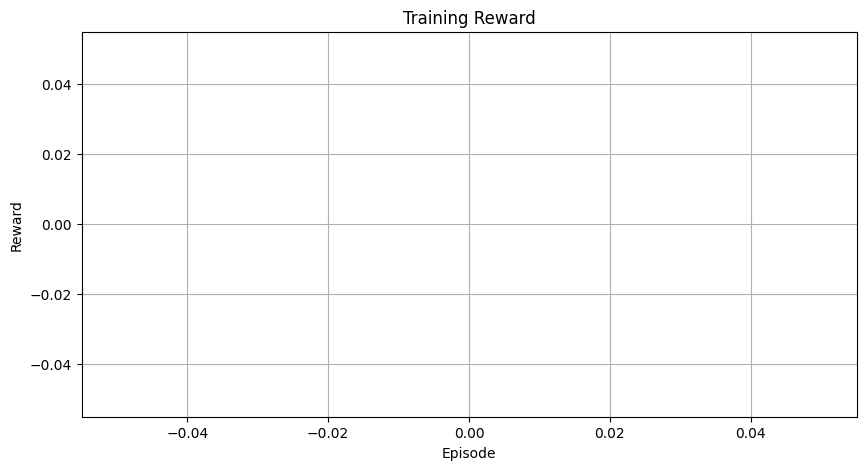

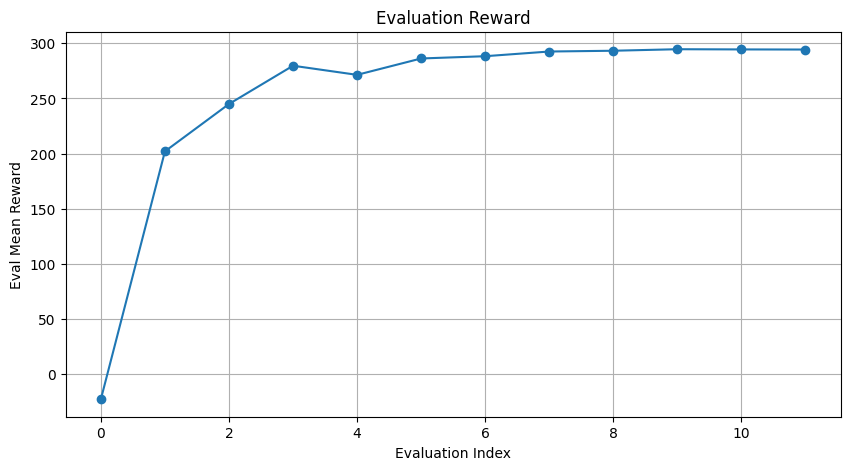

In [37]:
plt.figure(figsize=(10,5))
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Training Reward")
plt.grid(True)
plt.show()

window=50
if len(episode_rewards)>=window:
    smoothed=np.convolve(episode_rewards,np.ones(window)/window,mode="valid")
    plt.figure(figsize=(10,5))
    plt.plot(smoothed)
    plt.xlabel("Episode")
    plt.ylabel("Smoothed Reward")
    plt.title("Smoothed Training Reward")
    plt.grid(True)
    plt.show()

plt.figure(figsize=(10,5))
plt.plot(eval_history,marker="o")
plt.xlabel("Evaluation Index")
plt.ylabel("Eval Mean Reward")
plt.title("Evaluation Reward")
plt.grid(True)
plt.show()

This part visualizes the learning progress of the PPO agent. The raw training reward curve shows how episode rewards change during training, the smoothed training curve makes the long-term trend easier to see, and the evaluation curve shows how the agent’s mean performance improves over time. Together, these plots provide a clearer picture of whether the agent is learning successfully and help summarize the final training results.